# Homework 03
L. N. Jakubczyk

DATA 71200 | Spring 2026

# Multiple Regression Models: Shopping Behavior

This notebook builds and contrasts two multiple regression models to explain variation in purchase amount (USD). I fit both models on the full dataset first and evaluate which fits best, then fit the same two models separately for males and females and compare them. The data include integer, ordinal, and categorical variables, so I recode where needed before fitting.

## How to run this notebook

Open in Jupyter Notebook and run all cells. Dependencies are installed automatically by the first cell.

Model claude-sonnet-4-6 used for boilerplate setup only; analysis and interpretation are my own.

## 1. Setup and Data Loading

In [15]:
# install dependencies if missing (xlrd for .xls, openpyxl for .xlsx)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "pandas", "numpy", "matplotlib", "seaborn",
                       "scikit-learn", "openpyxl", "xlrd"])

import pandas as pd                                  # data
import numpy as np                                   # numerical
import matplotlib.pyplot as plt                      # plotting
import seaborn as sns                                # heatmaps if needed
from sklearn.linear_model import LinearRegression    # OLS regression
from sklearn.metrics import r2_score, mean_squared_error

# this Excel file has column names in the first row
df = pd.read_excel("03_shopping_behavior_updated.xls")

# drop any row that has at least one missing value
# doing this once here means all models run on the same N, so R^2 is comparable across models
df = df.dropna()
print("Shape (complete cases):", df.shape)
print(df.head(10))

Shape (complete cases): (3900, 16)
   Customer ID  Age Gender Item Purchased     Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse     Clothing                     53   
1            2   19   Male        Sweater     Clothing                     64   
2            3   50   Male          Jeans     Clothing                     73   
3            4   21   Male        Sandals     Footwear                     90   
4            5   45   Male         Blouse     Clothing                     49   
5            6   46   Male       Sneakers     Footwear                     20   
6            7   63   Male          Shirt     Clothing                     85   
7            8   27   Male         Shorts     Clothing                     34   
8            9   26   Male           Coat    Outerwear                     97   
9           10   57   Male        Handbag  Accessories                     31   

        Location Size      Color  Season  Review Rating Subscription Stat

## 2. Outcome and Recoding

**Y** = Purchase Amount (USD). I recode ordinal and categorical variables so they can go into regression (dummy coding for nominal fields, ordered numbers for size and frequency). The next cell finishes recoding, then plots a correlation matrix and a histogram of purchase amount before I fit any models.

Sample of recoded variables:
   Purchase Amount (USD)  Male  Size_ord  Freq_ord  Subscription  Discount
0                     53     1         3         5             1         1
1                     64     1         3         5             1         1
2                     73     1         1         7             1         1
3                     90     1         2         7             1         1
4                     49     1         2         1             1         1
5                     20     1         2         7             1         1
6                     85     1         2         3             1         1
7                     34     1         3         7             1         1


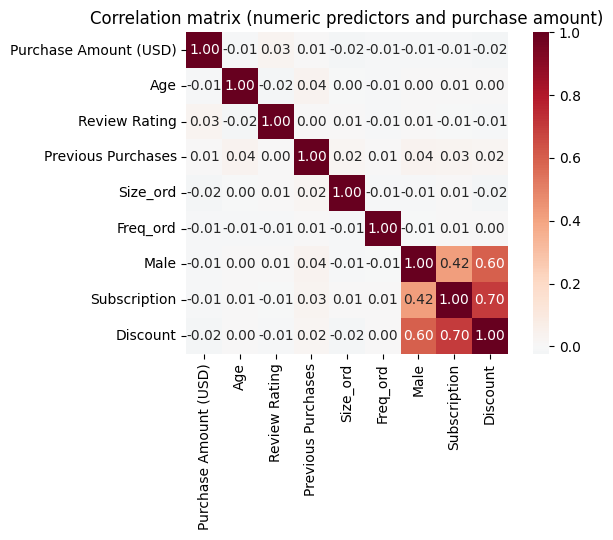

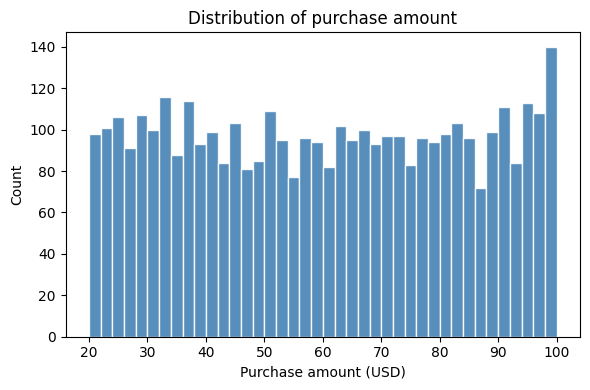

In [16]:
# define y once since the outcome is the same across all models
y = df["Purchase Amount (USD)"]

# Gender: 0=Female, 1=Male. Intercept = mean Y for females; coef = male vs female difference.
df["Male"] = (df["Gender"] == "Male").astype(int)

# Size: ordinal 1-4 (S to XL). Treating as continuous so coef = change in Y per step up in size.
size_map = {"S": 1, "M": 2, "L": 3, "XL": 4}
df["Size_ord"] = df["Size"].map(size_map)

# Frequency: ordinal 1 (Annually) to 7 (Weekly), least to most frequent
freq_order = ["Annually", "Every 3 Months", "Quarterly", "Monthly", "Fortnightly", "Bi-Weekly", "Weekly"]
df["Freq_ord"] = df["Frequency of Purchases"].map({f: i+1 for i, f in enumerate(freq_order)})

# Subscription and Discount: 1/0. Coef = mean difference in Y (Yes vs No).
df["Subscription"] = (df["Subscription Status"] == "Yes").astype(int)
df["Discount"] = (df["Discount Applied"] == "Yes").astype(int)

# Category: dummy coding. drop_first=True so one category is reference (avoids dummy variable trap)
cat_dummies = pd.get_dummies(df["Category"], prefix="Cat", drop_first=True)
df = pd.concat([df, cat_dummies], axis=1)

# Season: same idea, one reference level
season_dummies = pd.get_dummies(df["Season"], prefix="Season", drop_first=True)
df = pd.concat([df, season_dummies], axis=1)

print("Sample of recoded variables:")
print(df[["Purchase Amount (USD)", "Male", "Size_ord", "Freq_ord", "Subscription", "Discount"]].head(8))

# before fitting models, pairwise correlations among numeric predictors and Y (same idea as HW02)
num_cols = [
    "Purchase Amount (USD)", "Age", "Review Rating", "Previous Purchases",
    "Size_ord", "Freq_ord", "Male", "Subscription", "Discount",
]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, ax=ax)
ax.set_title("Correlation matrix (numeric predictors and purchase amount)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(y, bins=40, color="steelblue", edgecolor="white", alpha=0.9)
ax.set_xlabel("Purchase amount (USD)")
ax.set_ylabel("Count")
ax.set_title("Distribution of purchase amount")
plt.tight_layout()
plt.show()

## 3. Two Competing Models

- **Model A (Behavior/Loyalty):** Age, Gender, Review Rating, Previous Purchases, Size (ordinal), Subscription, Discount, Frequency (ordinal). Focus is on demographics and shopping behavior.
- **Model B (Product/Context):** Age, Gender, Review Rating, Previous Purchases, Size (ordinal), Category dummies, Season dummies. Same demographics plus product category and season.

In [17]:
# Model A: behavior/loyalty (demographics, satisfaction, history, size, subscription, discount, frequency)
cols_A = ["Age", "Male", "Review Rating", "Previous Purchases", "Size_ord", "Subscription", "Discount", "Freq_ord"]
# Model B: same plus category and season dummies (Cat_* and Season_* columns from get_dummies)
cols_B = ["Age", "Male", "Review Rating", "Previous Purchases", "Size_ord"] + [c for c in df.columns if c.startswith("Cat_") or c.startswith("Season_")]

X_A = df[cols_A]   # sklearn expects X 2D (rows = observations, columns = predictors)
X_B = df[cols_B]

model_A = LinearRegression().fit(X_A, y)
model_B = LinearRegression().fit(X_B, y)

# .score() returns R^2
r2_A = model_A.score(X_A, y)
r2_B = model_B.score(X_B, y)
n, p_A, p_B = len(y), X_A.shape[1], X_B.shape[1]
# adjusted R^2 penalizes extra predictors so we can compare models with different p
adj_r2_A = 1 - (1 - r2_A) * (n - 1) / (n - p_A - 1)
adj_r2_B = 1 - (1 - r2_B) * (n - 1) / (n - p_B - 1)

print("Full data (N =", n, ")")
print("Model A (Behavior/Loyalty)  R2:", round(r2_A, 4), "  Adj R2:", round(adj_r2_A, 4))
print("Model B (Product/Context)   R2:", round(r2_B, 4), "  Adj R2:", round(adj_r2_B, 4))

Full data (N = 3900 )
Model A (Behavior/Loyalty)  R2: 0.0022   Adj R2: 0.0001
Model B (Product/Context)   R2: 0.006   Adj R2: 0.0032


## 4. Full-Data Model Comparison Table

,Model,R2,Adj_R2,RMSE
0,Model A (Behavior/Loyalty),0.002151,0.00010,23.656866
1,Model B (Product/Context),0.005982,0.00317,23.611413


Best fit on full data: Model B


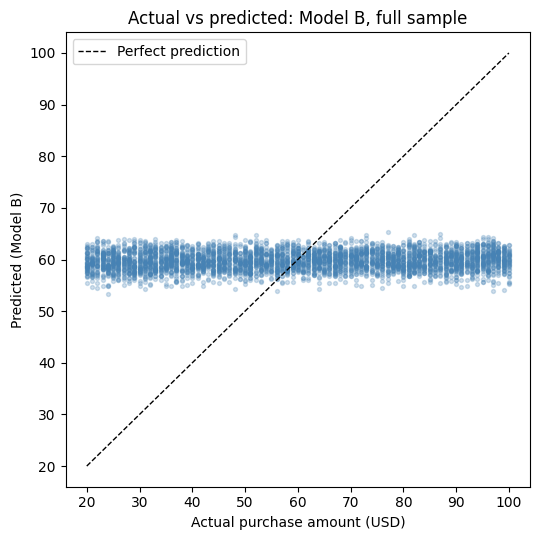

In [18]:
# pull R^2, adjusted R^2, and RMSE from each fitted model (RMSE in same units as Y, lower is better)
full_compare = pd.DataFrame({
    "Model": ["Model A (Behavior/Loyalty)", "Model B (Product/Context)"],
    "R2": [r2_A, r2_B],
    "Adj_R2": [adj_r2_A, adj_r2_B],
    "RMSE": [np.sqrt(mean_squared_error(y, model_A.predict(X_A))), np.sqrt(mean_squared_error(y, model_B.predict(X_B)))]
})
display(full_compare)

# grab the winner for the full-data comparison
best_full = "Model A" if r2_A >= r2_B else "Model B"
print("Best fit on full data:", best_full)

# actual vs predicted for Model B on the full sample (if fit were strong, points would hug the diagonal)
pred_B = model_B.predict(X_B)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y, pred_B, alpha=0.25, s=8, c="steelblue")
lims = [y.min(), y.max()]
ax.plot(lims, lims, "k--", lw=1, label="Perfect prediction")
ax.set_xlabel("Actual purchase amount (USD)")
ax.set_ylabel("Predicted (Model B)")
ax.set_title("Actual vs predicted: Model B, full sample")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Fit Same Two Models by Gender

I fit Model A and Model B separately for males and for females. In the subgroup models I leave out the Gender predictor (no variation within group).

,Group,N,Model A R2,Model B R2
0,Males,2652,0.002781,0.009017
1,Females,1248,0.002496,0.003654


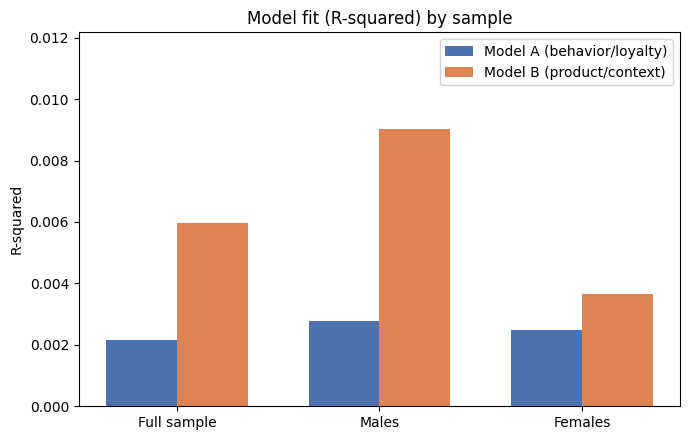

In [19]:
# within males or females there's no variation in Gender, so we drop it (would be collinear with intercept)
# same two model specs, just no Male indicator
cols_A_no_gender = ["Age", "Review Rating", "Previous Purchases", "Size_ord", "Subscription", "Discount", "Freq_ord"]
cols_B_no_gender = ["Age", "Review Rating", "Previous Purchases", "Size_ord"] + [c for c in df.columns if c.startswith("Cat_") or c.startswith("Season_")]

male = df["Male"] == 1
female = df["Male"] == 0
y_m, y_f = y[male], y[female]
X_A_m = df.loc[male, cols_A_no_gender]
X_A_f = df.loc[female, cols_A_no_gender]
X_B_m = df.loc[male, cols_B_no_gender]
X_B_f = df.loc[female, cols_B_no_gender]

# fit Model A and Model B in each subgroup (four models total)
mA_m = LinearRegression().fit(X_A_m, y_m)
mA_f = LinearRegression().fit(X_A_f, y_f)
mB_m = LinearRegression().fit(X_B_m, y_m)
mB_f = LinearRegression().fit(X_B_f, y_f)

results = []
for name, y_sub, X_A_sub, X_B_sub, mA, mB in [
    ("Males", y_m, X_A_m, X_B_m, mA_m, mB_m),
    ("Females", y_f, X_A_f, X_B_f, mA_f, mB_f)
]:
    r2_A_sub = mA.score(X_A_sub, y_sub)
    r2_B_sub = mB.score(X_B_sub, y_sub)
    n_sub = len(y_sub)
    results.append({"Group": name, "N": n_sub, "Model A R2": r2_A_sub, "Model B R2": r2_B_sub})

by_gender = pd.DataFrame(results)
display(by_gender)

# bar chart: R^2 for Model A vs B on full data and within each gender
r2_A_m = mA_m.score(X_A_m, y_m)
r2_B_m = mB_m.score(X_B_m, y_m)
r2_A_f = mA_f.score(X_A_f, y_f)
r2_B_f = mB_f.score(X_B_f, y_f)
labels = ["Full sample", "Males", "Females"]
a_vals = [r2_A, r2_A_m, r2_A_f]
b_vals = [r2_B, r2_B_m, r2_B_f]
x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - w / 2, a_vals, w, label="Model A (behavior/loyalty)", color="#4C72B0")
ax.bar(x + w / 2, b_vals, w, label="Model B (product/context)", color="#DD8452")
ax.set_ylabel("R-squared")
ax.set_title("Model fit (R-squared) by sample")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, max(max(a_vals), max(b_vals)) * 1.35)
plt.tight_layout()
plt.show()

## 6. Summary Table: Best Model by Group

In [20]:
# add a column for which model has higher R^2 in each subgroup (axis=1 applies the lambda to each row)
by_gender["Best"] = by_gender.apply(lambda r: "Model A" if r["Model A R2"] >= r["Model B R2"] else "Model B", axis=1)
display(by_gender)
print("Evidence-based conclusion: which model fits best differs (or is the same) by subgroup as shown above.")

,Group,N,Model A R2,Model B R2,Best
0,Males,2652,0.002781,0.009017,Model B
1,Females,1248,0.002496,0.003654,Model B


Evidence-based conclusion: which model fits best differs (or is the same) by subgroup as shown above.


## 7. Brief interpretation

On the full dataset, Model B (Product/Context) has the higher R^2 and adjusted R^2, so it fits best overall. When I fit the same two models separately for males and females, Model B also has the higher R^2 in both subgroups (males: Model B about 0.009 vs. Model A about 0.003; females: Model B about 0.004 vs. Model A about 0.003). So the evidence points to the same conclusion: the model that includes category and season explains more variation in purchase amount than the behavior/loyalty model, both in the full sample and within each demographic group. The amount of variance explained is still low in all cases, which matches the correlation heatmap and the actual vs predicted scatter above.